# GOLEM Fast Spectrometer to Fast Cameras Comparison

This notebook loads and visualizes fast spectrometry data alongside fast camera data from the GOLEM tokamak, allowing for temporal comparison of diagnostics.

**Features:**
- Load fast spectrometry signals (especially WHOLE spectrum)
- Load fast camera data (Radial and Vertical)
- Generate comparative plots showing temporal correlations
- Visual analysis of plasma behavior across diagnostics

## Setup & Configuration

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from golem_data_loader import GolemDataLoader, SpectroscopyLine

# Default shot number
DEFAULT_SHOT = 50377

# Volume definitions (mm³)
VOLUME_SPEC = 41187        # Spectrometry volume
VOLUME_RADIAL = 42951      # Radial camera volume
VOLUME_VERTICAL = 1380.90625  # Vertical camera volume

# Color scheme for consistent visualization
COLORS = {
    'spectrum': '#2E86AB',      # Deep blue
    'camera_radial': '#A23B72', # Purple
    'camera_vertical': '#F18F01', # Orange
    'grid': '#CCCCCC'
}

# Figure styling
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


## Section 1: Data Loading Functions

In [5]:
def load_all_data(shot_number: int) -> dict:
    """
    Load fast spectrometry and fast camera data from GOLEM server.
    
    Args:
        shot_number: The GOLEM shot number
        
    Returns:
        Dictionary containing loaded data with keys:
        - 'spectrum': Fast spectrometry data
        - 'cameras': Fast camera data
        - 'shot': Shot number
    """
    print(f"\n{'='*70}")
    print(f"LOADING DATA FOR SHOT {shot_number}")
    print(f"{'='*70}\n")
    
    loader = GolemDataLoader(shot_number=shot_number)
    data_container = {'shot': shot_number}
    
    # Load fast spectrometry (WHOLE spectrum only)
    print("► Loading Fast Spectrometry (WHOLE spectrum)...")
    try:
        spec_data = loader.load_fast_spectrometry(lines=[SpectroscopyLine.WHOLE])
        data_container['spectrum'] = spec_data['Whole']
        print(f"  ✓ Loaded {len(data_container['spectrum'].time)} spectral data points")
        print(f"    Time range: {data_container['spectrum'].time[0]:.4f}s - {data_container['spectrum'].time[-1]:.4f}s")
        print(f"    Intensity: {data_container['spectrum'].intensity.min():.2f} - {data_container['spectrum'].intensity.max():.2f} a.u.")
    except Exception as e:
        print(f"  ✗ Error loading spectrometry: {e}")
        data_container['spectrum'] = None
    
    # Load fast camera data
    print("\n► Loading Fast Camera Data (Radial & Vertical)...")
    try:
        cameras = loader.load_fast_cameras()
        data_container['cameras'] = cameras
        for cam_name, cam_data in cameras.items():
            print(f"  ✓ {cam_name.capitalize()}: {cam_data.frames.shape[0]} frames @ {cam_data.frame_rate:.0f} fps")
            print(f"    Duration: {cam_data.time[-1]*1000:.2f} ms")
    except Exception as e:
        print(f"  ✗ Error loading cameras: {e}")
        data_container['cameras'] = None
    
    print()
    return data_container

## Section 2: Spectrometry Visualization

In [6]:
def plot_spectrometry(data_container: dict) -> None:
    """
    Plot fast spectrometry WHOLE spectrum over time.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None:
        print("✗ No spectrometry data available")
        return
    
    print("► Generating Spectrometry Plot...")
    
    spectrum = data_container['spectrum']
    shot = data_container['shot']
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot spectrum
    ax.plot(spectrum.time * 1e3, spectrum.intensity, 
            linewidth=1.5, color=COLORS['spectrum'], label='WHOLE Spectrum')
    
    # Styling
    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
    ax.set_title(f'Fast Spectrometry - WHOLE Spectrum | Shot {shot}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])
    ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Spectrometry plot displayed\n")

## Section 3: Fast Cameras Visualization

In [7]:
def plot_fast_cameras(data_container: dict, max_frames: int = 400) -> None:
    """
    Plot fast camera data as temporal sequences.
    
    Args:
        data_container: Dictionary containing loaded data
        max_frames: Maximum number of frames to display
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print(f"► Generating Fast Camera Plots (max {max_frames} frames)...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    # Create subplots for each camera
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Limit frames for display
        n_frames = min(max_frames, cam_data.frames.shape[0])
        frames_subset = cam_data.frames[:n_frames]
        time_subset = cam_data.time[:n_frames] * 1e3
        
        # Reshape for display: (frames, height, width)
        if len(frames_subset.shape) == 3:
            display_data = np.mean(frames_subset, axis=2)  # Average RGB channels
        else:
            display_data = frames_subset
        
        # Transpose for proper visualization (time on x, spatial on y)
        im = ax.imshow(display_data.T, aspect='auto', cmap='gray', 
                       extent=[time_subset[0], time_subset[-1], 0, display_data.shape[1]],
                       interpolation='nearest', origin='lower')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Spatial Position (pixels)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Fast Camera (80k fps) | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Intensity (a.u.)')
    
    plt.tight_layout()
    plt.show()
    print(f"  ✓ Fast camera plots displayed\n")

## Section 4: Combined Comparison

## Section 5: Camera Temporal Averaging

In [ ]:
def plot_camera_temporal_average(data_container: dict) -> None:
    """
    Plot per-frame pixel-averaged camera intensity over time.
    Averages all pixel values in each frame to create a temporal signal.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print("► Generating Camera Temporal Average Plots...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Get frames and average all pixels in each frame
        frames = cam_data.frames
        
        # Handle RGB channels if present
        if len(frames.shape) == 3:
            display_data = np.mean(frames, axis=2)  # Average RGB channels first
        else:
            display_data = frames
        
        # Apply ROI for vertical camera before averaging
        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]
        
        # Average over all spatial dimensions per frame (all pixels averaged for each frame)
        # This creates a single value per frame
        temporal_average = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        time_ms = cam_data.time * 1e3
        
        # Plot
        ax.plot(time_ms, temporal_average, linewidth=1.5, color=COLORS['camera_radial'], 
                label=f'{cam_name.capitalize()} - Pixel Average')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Pixel-Averaged Intensity (a.u.)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Camera - Per-Frame Pixel Average | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Camera temporal average plots displayed\n")

In [ ]:
def plot_comparison(data_container: dict) -> None:
    """
    Create a single unified plot showing all three diagnostic signals on one axis.
    Applies time offset correction to align spectrometry with camera start time.
    Normalizes signals by their respective volumes (a.u. per mm³).
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None or data_container['cameras'] is None:
        print("✗ Incomplete data for comparison (need both spectrum and cameras)")
        return
    
    print("► Generating Comparison Plot...")
    
    spectrum = data_container['spectrum']
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    # Get reference time (camera start, which should be t=0)
    camera_ref_time = next(iter(cameras.values())).time[0]
    spec_start_time = spectrum.time[0]
    time_offset = spec_start_time - camera_ref_time
    
    print("\n  TIME DIAGNOSTICS (BEFORE CORRECTION):")
    print(f"  Spectrometry: t_start={spectrum.time[0]*1e3:.4f} ms")
    for cam_name, cam_data in cameras.items():
        print(f"  {cam_name.capitalize()}: t_start={cam_data.time[0]*1e3:.4f} ms")
    
    print(f"\n  TIME OFFSET: {time_offset*1e3:.4f} ms ({time_offset*1e6:.2f} µs)")
    
    # Apply time offset correction to spectrum
    spectrum_time_corrected = spectrum.time - time_offset
    
    print(f"\n  TIME DIAGNOSTICS (AFTER CORRECTION):")
    print(f"  Spectrometry: t_start={spectrum_time_corrected[0]*1e3:.4f} ms, t_end={spectrum_time_corrected[-1]*1e3:.4f} ms")
    for cam_name, cam_data in cameras.items():
        print(f"  {cam_name.capitalize()}: t_start={cam_data.time[0]*1e3:.4f} ms, t_end={cam_data.time[-1]*1e3:.4f} ms")
    
    # Find common time range (intersection of all signals)
    time_min = spectrum_time_corrected.min()
    time_max = spectrum_time_corrected.max()
    
    for cam_data in cameras.values():
        time_min = max(time_min, cam_data.time.min())
        time_max = min(time_max, cam_data.time.max())
    
    print(f"\n  Common time range: {time_min*1e3:.2f} - {time_max*1e3:.2f} ms")
    print(f"\n  VOLUME NORMALIZATION:")
    print(f"  Spectrometry volume: {VOLUME_SPEC:,} mm³")
    print(f"  Radial camera volume: {VOLUME_RADIAL:,} mm³")
    print(f"  Vertical camera volume: {VOLUME_VERTICAL:,} mm³")
    
    # Create common time grid at spectrometry resolution
    common_time = np.linspace(time_min, time_max, len(spectrum.time))
    common_time_ms = common_time * 1e3
    
    # Create single figure with one plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Interpolate spectrum to common time grid (using corrected time)
    # Normalize by volume
    spectrum_interp = np.interp(common_time, spectrum_time_corrected, spectrum.intensity)
    spectrum_normalized = spectrum_interp / VOLUME_SPEC
    ax.plot(common_time_ms / 2, spectrum_normalized * 10, 
            linewidth=2, color=COLORS['spectrum'], label='WHOLE Spectrum', alpha=0.8)
    
    # Plot camera signals (interpolated to common time grid)
    for idx, (cam_name, cam_data) in enumerate(cameras.items()):
        # Prepare data
        frames = cam_data.frames
        if len(frames.shape) == 3:
            display_data = np.mean(frames, axis=2)  # Average RGB channels
        else:
            display_data = frames
        
        # Apply ROI for vertical camera before averaging
        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]
        
        # Calculate pixel average per frame
        pixel_avg = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        
        # Select appropriate volume for this camera
        camera_volume = VOLUME_VERTICAL if cam_name == 'vertical' else VOLUME_RADIAL
        pixel_avg_normalized = pixel_avg / camera_volume
        
        # Interpolate camera data to common time grid
        camera_interp = np.interp(common_time, cam_data.time, pixel_avg_normalized)
        
        # Plot on same axis
        color = COLORS['camera_vertical'] if idx > 0 else COLORS['camera_radial']
        ax.plot(common_time_ms, camera_interp, linewidth=2, 
                color=color, label=f'{cam_name.capitalize()} - Pixel Avg', alpha=0.8)
    
    # Axis styling
    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity per Volume (a.u./mm³)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=11)
    
    # Title and layout
    plt.title(f'GOLEM Multi-Diagnostic Temporal Comparison | Shot {shot} (Time-Corrected, Volume-Normalized)', 
              fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
    print("\n  ✓ Comparison plot displayed\n")

## Section 5: Analysis Configuration & Execution

In [10]:
# ============================================================================
# CONFIGURE SHOT NUMBER HERE
# ============================================================================
SHOT_TO_ANALYZE = 50730


  # ← CHANGE THIS VALUE TO ANALYZE A DIFFERENT SHOT

2026-02-13 11:20:56,191 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/PlasmaDetection/Results/t_plasma_start



RUNNING ANALYSIS FOR SHOT 50730


LOADING DATA FOR SHOT 50730



2026-02-13 11:20:57,249 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/PlasmaDetection/Results/t_plasma_end
2026-02-13 11:20:57,250 - golem_data_loader.golem_data_loader - INFO - Loaded plasma timing: 2.93 - 15.31 ms


► Loading Fast Spectrometry (WHOLE spectrum)...


2026-02-13 11:20:58,464 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Whole spectrometry from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastSpectrometry/DAS_raw_data_dir/ch6.csv
2026-02-13 11:20:58,486 - golem_data_loader.golem_data_loader - INFO - Whole: loaded 19999 rows, columns = ['    0', '0.002']
2026-02-13 11:20:58,486 - golem_data_loader.golem_data_loader - INFO - Loading Fast Camera (Radial) frames...
2026-02-13 11:20:58,529 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 1 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/1.png
2026-02-13 11:20:58,589 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 2 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/2.png


  ✓ Loaded 19999 spectral data points
    Time range: 0.0000s - 0.0400s
    Intensity: -0.00 - 5.08 a.u.

► Loading Fast Camera Data (Radial & Vertical)...


2026-02-13 11:20:59,631 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 3 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/3.png
2026-02-13 11:20:59,727 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 4 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/4.png
2026-02-13 11:21:00,801 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 5 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/5.png
2026-02-13 11:21:01,847 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 6 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/6.png
2026-02-13 11:21:02,888 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 7 from http://golem.fjfi.c

  ✓ Radial: 1599 frames @ 80000 fps
    Duration: 19.98 ms
  ✓ Vertical: 1599 frames @ 80000 fps
    Duration: 19.98 ms

► Generating Comparison Plot...

  TIME DIAGNOSTICS (BEFORE CORRECTION):
  Spectrometry: t_start=0.0020 ms
  Radial: t_start=0.0000 ms
  Vertical: t_start=0.0000 ms

  TIME OFFSET: 0.0020 ms (2.00 µs)

  TIME DIAGNOSTICS (AFTER CORRECTION):
  Spectrometry: t_start=0.0000 ms, t_end=39.9980 ms
  Radial: t_start=0.0000 ms, t_end=19.9750 ms
  Vertical: t_start=0.0000 ms, t_end=19.9750 ms

  Common time range: 0.00 - 19.98 ms

  VOLUME NORMALIZATION:
  Spectrometry volume: 41,187 mm³
  Camera volume: 42,951 mm³


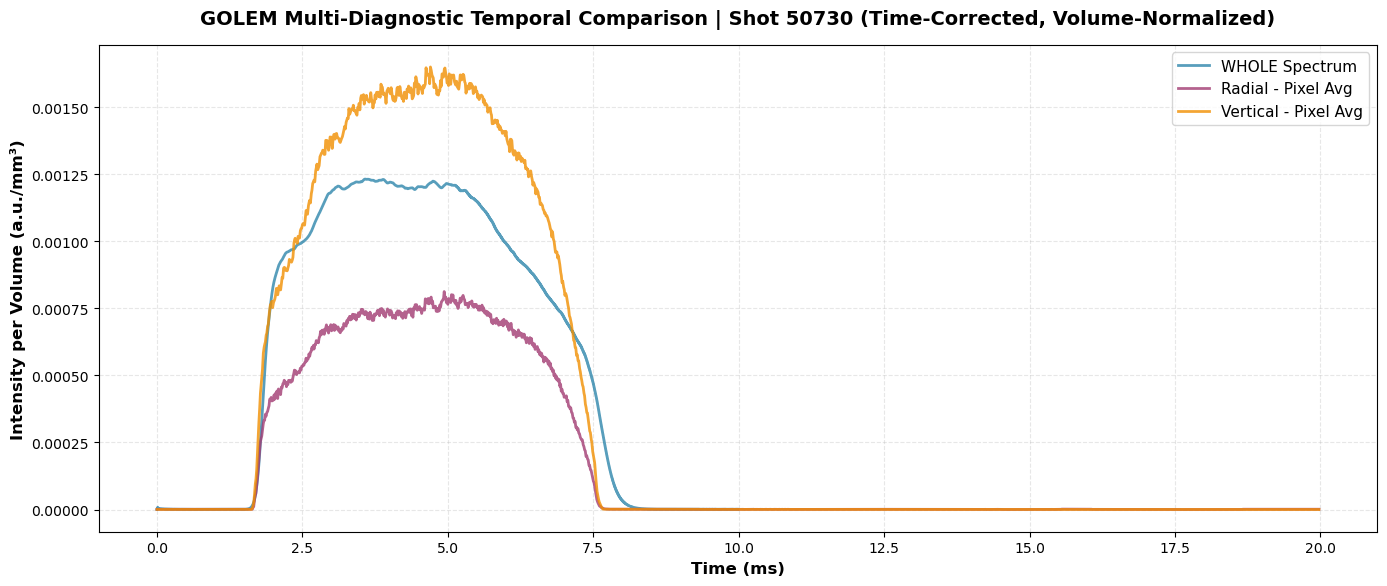


  ✓ Comparison plot displayed

ANALYSIS COMPLETE



In [11]:
# Load data and generate combined comparison plot
print(f"\n{'='*70}")
print(f"RUNNING ANALYSIS FOR SHOT {SHOT_TO_ANALYZE}")
print(f"{'='*70}\n")

data = load_all_data(SHOT_TO_ANALYZE)
plot_comparison(data)

print(f"{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}\n")

► Generating Comparison Plot...

  TIME DIAGNOSTICS (BEFORE CORRECTION):
  Spectrometry: t_start=0.0020 ms
  Radial: t_start=0.0000 ms
  Vertical: t_start=0.0000 ms

  TIME OFFSET: 0.0020 ms (2.00 µs)

  TIME DIAGNOSTICS (AFTER CORRECTION):
  Spectrometry: t_start=0.0000 ms, t_end=39.9980 ms
  Radial: t_start=0.0000 ms, t_end=19.9750 ms
  Vertical: t_start=0.0000 ms, t_end=19.9750 ms

  Common time range: 0.00 - 19.98 ms

  VOLUME NORMALIZATION:
  Spectrometry volume: 41,187 mm³
  Camera volume: 42,951 mm³


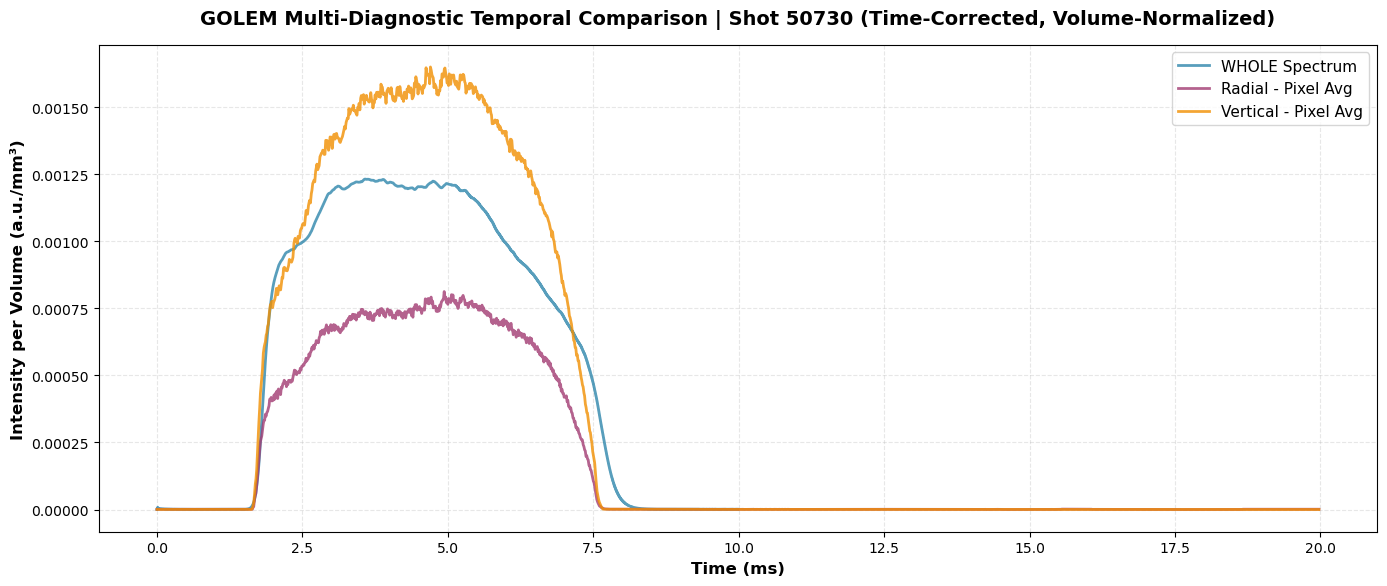


  ✓ Comparison plot displayed



In [12]:
# Generate combined comparison visualization
plot_comparison(data)

## Done!

Change the `SHOT_TO_ANALYZE` value in the configuration cell above and run the analysis cell to generate all graphs for your desired shot.